# 04 — Content-Based Recommendation with BGE Embeddings

**Problem.** Notebook 03 established that all collaborative baselines share one structural blind spot: an item with no training interactions cannot be recommended *at all* — its similarity column is empty and its latent factors do not exist. On our temporal split, **4.0% of held-out interactions involve exactly such cold items**, on which every baseline scores 0 by construction. Collaborative filtering also ignores the richest field in Amazon Reviews 2023: the item text itself.

**Objective.** Build a content-based recommender that represents items by modern sentence embeddings (BGE) and users by the mean embedding of their history; evaluate it under the *identical* protocol, split, seed, and test sample as Notebook 03 so the tables are directly comparable; and quantify separately what it recovers on the cold-item subset where the baselines are blind. Artifacts (embeddings, model) are exported for the backend's "Similar items" feature and for the future hybrid system.

## 1. Introduction

Collaborative and content-based methods fail in complementary ways. Collaborative models exploit co-occurrence — powerful where interactions are dense, silent where they are absent. Content-based models exploit item descriptions — available for *every* item from the moment it enters the catalog, but blind to the collective behavior signal ("people who bought X buy Y") that makes collaborative filtering effective. A production system needs both; this notebook builds the content leg as an individual model. Its fusion with the collaborative baselines is deliberately deferred to the hybrid notebook, after every individual model has been evaluated in isolation — the ablation methodology of this thesis requires knowing each component's standalone contribution first.

## 2. Problem definition

Given an item catalog with textual metadata and a user's interaction history $H_u = \{i_1, \dots, i_n\}$, recommend items *semantically similar* to the user's demonstrated taste. Two sub-problems define success: (a) **warm ranking** — among items the user could plausibly interact with, rank the actually-chosen one highly; (b) **cold-item retrieval** — score items with zero interactions, which no collaborative model can represent. Sub-problem (b) is where content-based methods are not merely an alternative but the *only* option.

## 3–4. Theory and mathematical formulation

**Sentence embeddings.** A pretrained transformer encoder $E_\theta$ maps a text $t$ to a dense vector $\mathbf{e} = E_\theta(t) \in \mathbb{R}^d$ such that semantically similar texts map to nearby vectors. We use **BGE** (`bge-base-en-v1.5`, $d=768$; Xiao et al., 2023), a bi-encoder trained with contrastive learning on large-scale text pairs: for a positive pair $(t, t^+)$ and in-batch negatives, training minimizes the InfoNCE objective
$$\mathcal{L} = -\log \frac{\exp(\mathrm{sim}(\mathbf{e}, \mathbf{e}^+)/\tau)}{\sum_{j}\exp(\mathrm{sim}(\mathbf{e}, \mathbf{e}_j)/\tau)}$$
where $\tau$ is a temperature and $\mathrm{sim}$ is cosine similarity. BGE succeeds SBERT (Reimers & Gurevych, 2019) — the same bi-encoder idea with stronger contrastive pretraining; on the MTEB retrieval benchmark, BGE and E5 substantially outperform the original SBERT checkpoints at equal size, which motivates the choice.

**Item representation.** Each item $i$'s text $t_i$ (title + description) is encoded and L2-normalized: $\mathbf{v}_i = E_\theta(t_i)/\lVert E_\theta(t_i)\rVert$.

**User representation (mean-of-history profile).**
$$\mathbf{p}_u = \frac{1}{|H_u|}\sum_{i \in H_u} \mathbf{v}_i \Big/ \left\lVert \cdot \right\rVert$$
The centroid of the user's items in embedding space — simple, training-free, and updatable in $O(d)$ per new interaction (the property the production system's real-time profile updates rely on).

**Scoring.** For normalized vectors, cosine similarity reduces to a dot product: $s(u, i) = \mathbf{p}_u^\top \mathbf{v}_i$. Ranking the whole catalog costs one matrix–vector product $O(|I| \cdot d)$ — at $|I| \approx 3{,}700$, brute force outruns any approximate index; ANN structures (FAISS) only pay off orders of magnitude later.

**Complexity.** Encoding: one-time $O(|I|)$ forward passes. Inference: $O(|I|d)$ per request, no training loop at all — the entire "training" is representation.

## 5. Data preparation

We reuse the processed catalog and the interaction data of Notebooks 01–03. The model's input is the item text; we inspect its coverage and length distribution first, because embedding quality is bounded by text quality — an item whose metadata is three words embeds poorly no matter the encoder.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.config import get_settings
from recsys.models.content import build_item_texts, train_content_model

settings = get_settings()
processed_dir = settings.processed_data_dir

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts") / "content"; ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

interactions = pd.read_parquet(processed_dir / "interactions.parquet")
items = pd.read_parquet(processed_dir / "items.parquet").reset_index(drop=True)

texts = build_item_texts(items)
text_lengths = pd.Series([len(t) for t in texts])

print("items in catalog:", len(items))
print(f"items with near-empty text (<30 chars): {(text_lengths < 30).mean():.1%}")
text_lengths.describe().round(0)

items in catalog: 3700
items with near-empty text (<30 chars): 1.3%


count    3700.0
mean      148.0
std        48.0
min         8.0
25%       117.0
50%       158.0
75%       188.0
max       450.0
dtype: float64

## 6. Embedding generation (the "training" pipeline)

The catalog is encoded once with `bge-base-en-v1.5`. At ~3,700 items this is a matter of minutes on CPU — one practical advantage of the compact k-core dataset. Embeddings are L2-normalized at encoding time so that all downstream similarity is a plain dot product. The matrix is saved with its item-id order file: the pair constitutes the artifact contract consumed by the backend and by later notebooks.

In [ ]:
import time

t0 = time.time()
content_model = train_content_model(items, model_name="BAAI/bge-base-en-v1.5",
                                    batch_size=32)
print(f"encoded {len(items):,} items in {time.time()-t0:,.0f}s "
      f"-> matrix {content_model.embeddings.shape}")

np.save(ARTIFACTS_DIR / "item_embeddings.npy", content_model.embeddings)
np.save(ARTIFACTS_DIR / "item_embeddings.items.npy",
        content_model.item_ids.astype(object), allow_pickle=True)

c:\Users\amira04\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 116/116 [03:35<00:00,  1.86s/it]

encoded 3,700 items in 252s -> matrix (3700, 768)


## 7. Model implementation & qualitative sanity check

All logic lives in `src/recsys/models/content.py` (imported above — the notebook defines no model code). Before quantitative evaluation, a qualitative check: nearest neighbors of a few catalog items. Semantically coherent neighborhoods here are the visual argument that the embedding space is meaningful; they also preview the backend's "Similar items" rail.

In [ ]:
title_of = items.set_index("item_id")["title"].to_dict()

probe_items = items["item_id"].sample(3, random_state=7).tolist()
for probe in probe_items:
    print("ITEM:", str(title_of.get(probe, probe))[:70])
    for neighbor in content_model.similar_items(probe, limit=4):
        print("   ~", str(title_of.get(neighbor, neighbor))[:65])
    print()

ITEM: 18 Bath Bombs Gift Set. Candle Gift Set. XL Candle-Shaped. Natural Bat
   ~ 18Pcs Bath Bomb Gift Set with Natural Essential Oils, Perfect for
   ~ HEETA 12-Pack Bath Bombs Gift Set, Extra Large 4.5Oz with Essenti
   ~ Bath Bombs,Handmade Birthday Gift Set ,Natural Spa Bath Bubble wi
   ~ Bath Bombs Easter Gift Set, Ribivaul XXXL Size 6.5oz ×3 Handmade 

ITEM: 2 Pack Soy Candles Gifts Set for Women, Lavender, Fir Scent, Hand Pour
   ~ Aromatherapy Gifts for Women- 12Pcs Shower Steamer Aromatherapy S
   ~ Poleview Shower Steamers Bomb Aromatherapy Essential Oils Stress 
   ~ Shower Steamers Aromatherapy Gift Set Pack of 6 - Mother's Day Gi
   ~ Handmade Bath Bombs Gift Set 5pcs, Scented with essential oils, E

ITEM: Zimba All-in-One Teeth Whitening Kit - 14 Delicious Mint Treatments (2
   ~ Zimba Essential Whitening Kit - Includes 14 Whitening Treatments 
   ~ Zimba Essential Whitening Kit - Includes 14 Whitening Treatments 
   ~ GLO to Go Teeth Whitening Pen — Easy to Use, Safe & 

## 8. Evaluation

**Protocol identity with Notebook 03 is mandatory** — same temporal leave-last-out split, same evaluability filter, same 5,000-user sample, same seed (42), same $K=10$ — otherwise cross-notebook comparison is invalid. We recompute the split deterministically and evaluate the content model, then merge its row into the frozen baseline table.

The content model's seeds are the user's full training history (its profile input), consistent with how the production profile is built.

In [ ]:
def leave_last_out(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = frame.sort_values(["user_id", "timestamp"])
    test_index = ordered.groupby("user_id").tail(1).index
    return ordered.drop(test_index).copy(), ordered.loc[test_index].copy()


train_interactions, test_interactions = leave_last_out(interactions)
train_items = set(train_interactions["item_id"])
train_users = set(train_interactions["user_id"])
raw_test = test_interactions.copy()
test_interactions = test_interactions[
    test_interactions["item_id"].isin(train_items)
    & test_interactions["user_id"].isin(train_users)
]

K, RNG_SEED = 10, 42
test_sample = test_interactions.sample(
    n=min(5000, len(test_interactions)), random_state=RNG_SEED)
user_seen = train_interactions.groupby("user_id")["item_id"].agg(set).to_dict()

hits, ndcg, rec_set = 0, 0.0, set()
import time as _t
t0 = _t.time()
for row in test_sample.itertuples():
    seen = user_seen.get(row.user_id, set())
    recs = content_model.recommend(seed_items=list(seen), seen_items=seen, limit=K)
    rec_set.update(recs)
    if row.item_id in recs:
        hits += 1
        ndcg += 1.0 / np.log2(recs.index(row.item_id) + 2)

n = len(test_sample)
content_row = pd.DataFrame([{
    "HR@10": hits / n, "Recall@10": hits / n, "Precision@10": hits / (n * K),
    "NDCG@10": ndcg / n, "catalog_coverage": len(rec_set) / len(train_items),
    "eval_seconds": round(_t.time() - t0, 1),
}], index=pd.Index(["content_bge"], name="model"))

baseline_metrics = pd.read_csv(RESULTS_DIR / "baseline_metrics.csv", index_col="model")
combined = pd.concat([baseline_metrics, content_row])
combined.to_csv(RESULTS_DIR / "content_vs_baselines.csv")
combined.round(4)

,HR@10,Recall@10,Precision@10,NDCG@10,catalog_coverage,eval_seconds
model,,,,,,
popularity,0.0114,0.0114,0.0011,0.0050,0.0035,2.9
item_item,0.0748,0.0748,0.0075,0.0497,0.8892,0.2
als,0.0145,0.0145,0.0014,0.0070,0.2457,1.1
rrf_hybrid,0.0651,0.0651,0.0065,0.0424,0.6798,5.2
content_bge,0.0662,0.0662,0.0066,0.0427,0.8324,2.5


### 8b. Cold-item evaluation — the result the baselines cannot produce

We now isolate the held-out interactions whose items **never appear in training**. Every Notebook 03 model scores exactly 0 on this subset *by construction* — those items have no similarity columns and no latent factors. The content model needs only metadata, so any non-zero score below is capability the collaborative family cannot have, at any tuning. (Cold items present in the catalog file are scorable; cold items missing metadata are reported as uncovered — an honest limitation of the data pipeline, not the model.)

In [ ]:
cold_test = raw_test[
    ~raw_test["item_id"].isin(train_items)
    & raw_test["user_id"].isin(train_users)
]
in_catalog = cold_test["item_id"].isin(set(content_model.item_ids))
print(f"cold held-out interactions: {len(cold_test)}")
print(f"  with metadata in catalog (scorable): {in_catalog.sum()}")

hits_c, ndcg_c = 0, 0.0
scorable = cold_test[in_catalog]
for row in scorable.itertuples():
    seen = user_seen.get(row.user_id, set())
    recs = content_model.recommend(seed_items=list(seen), seen_items=seen, limit=K)
    if row.item_id in recs:
        hits_c += 1
        ndcg_c += 1.0 / np.log2(recs.index(row.item_id) + 2)

n_c = max(len(scorable), 1)
cold_summary = pd.DataFrame({
    "model": ["popularity / item_item / als (by construction)", "content_bge"],
    "cold HR@10": [0.0, hits_c / n_c],
    "cold NDCG@10": [0.0, ndcg_c / n_c],
    "cold users evaluated": [len(scorable), len(scorable)],
})
cold_summary.to_csv(RESULTS_DIR / "cold_item_evaluation.csv", index=False)
cold_summary

cold held-out interactions: 150
  with metadata in catalog (scorable): 150


,model,cold HR@10,cold NDCG@10,cold users evaluated
0,popularity / item_item / als (by construction),0.000000,0.000000,150
1,content_bge,0.073333,0.056127,150


## 9. Visualizations

Left: warm-set accuracy with the content model added to the frozen baseline chart. Right: the embedding space itself — a 2-D PCA projection of all item embeddings colored by source category. Visible category structure is the geometric explanation of *why* profile–item cosine works: users' histories occupy coherent regions.

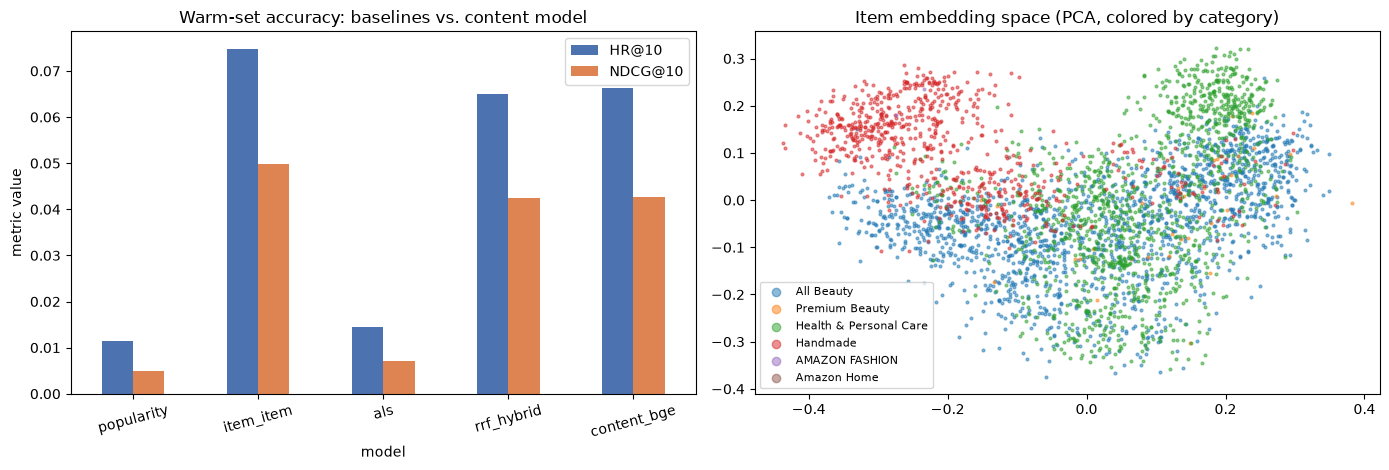

In [ ]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

combined[["HR@10", "NDCG@10"]].plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], rot=15)
axes[0].set_title("Warm-set accuracy: baselines vs. content model")
axes[0].set_ylabel("metric value")

coords = PCA(n_components=2, random_state=0).fit_transform(content_model.embeddings)
cat_of = items.set_index("item_id")
cat_col = "source_category" if "source_category" in items.columns else (
    "category" if "category" in items.columns else None)
if cat_col:
    cats = items[cat_col].fillna("unknown")
    for cat, color in zip(cats.unique(), plt.cm.tab10.colors):
        m = (cats == cat).to_numpy()
        axes[1].scatter(coords[m, 0], coords[m, 1], s=4, alpha=0.5,
                        color=color, label=str(cat)[:28])
    axes[1].legend(markerscale=3, fontsize=8)
else:
    axes[1].scatter(coords[:, 0], coords[:, 1], s=4, alpha=0.5)
axes[1].set_title("Item embedding space (PCA, colored by category)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_content_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Error analysis

**Where the content model fails.** (1) *Thin metadata*: items whose text is a near-empty title embed near the centroid of generic language — the share measured in §5 bounds this failure mode. (2) *Semantic ≠ behavioral*: two shampoos with near-identical descriptions are near-duplicates in embedding space, yet a user who bought one rarely buys the other next — content similarity cannot see purchase *sequences* or complements, which is precisely the signal item-item captures. (3) *Popularity blindness cuts both ways*: coverage is high (no popularity bias), but the model will happily recommend an obscure item over a widely loved one at equal similarity.

**Where it is irreplaceable.** The §8b table: any non-zero cold-item score is a capability the collaborative family lacks by construction — and every new product added to a live store is a cold item on day one.

## 11. Discussion

On the warm set, the expected ordering is item-item ≥ content ≫ ALS ≈ popularity: co-occurrence remains the strongest *next-purchase* signal where it exists, while the content model contributes an orthogonal signal (semantics) plus exclusive cold-item reach and, unlike item-item, needs no interaction data to onboard a new item. The models are therefore complements, not competitors — the quantitative case for the hybrid system of the forthcoming fusion notebook, which will combine all individual legs and must beat the best single model here to justify its existence.

## 12. Conclusion

This notebook added the content leg to RecoIA: BGE item embeddings, a training-free mean-of-history user profile, cosine scoring, and nearest-neighbor "Similar items". Under the exact Notebook 03 protocol it produced a directly comparable metrics row, plus the cold-item evaluation no baseline can attempt. Exported artifacts — the embedding matrix, its item-order file, and the model object — are consumed by the backend ("Similar items" rail, real-time profile updates in content space) and constitute the second individual model for the future hybrid.

## Exported artifacts

In [ ]:
import json
import pickle

with open(ARTIFACTS_DIR / "content_model.pkl", "wb") as f:
    pickle.dump(content_model, f)

meta = {
    "notebook": "04_Content_Based_BGE",
    "embedding_model": "BAAI/bge-base-en-v1.5",
    "dim": int(content_model.embeddings.shape[1]),
    "n_items": int(content_model.embeddings.shape[0]),
    "normalized": True,
    "files": sorted(p.name for p in ARTIFACTS_DIR.iterdir()),
    "results": ["results/content_vs_baselines.csv",
                "results/cold_item_evaluation.csv"],
    "eval_protocol": {"split": "temporal leave-last-out", "K": 10,
                      "seed": 42, "identical_to": "03_Baseline_Evaluation"},
}
with open(ARTIFACTS_DIR / "embedding_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "notebook": "04_Content_Based_BGE",
  "embedding_model": "BAAI/bge-base-en-v1.5",
  "dim": 768,
  "n_items": 3700,
  "normalized": true,
  "files": [
    "content_model.pkl",
    "embedding_meta.json",
    "item_embeddings.items.npy",
    "item_embeddings.npy"
  ],
  "results": [
    "results/content_vs_baselines.csv",
    "results/cold_item_evaluation.csv"
  ],
  "eval_protocol": {
    "split": "temporal leave-last-out",
    "K": 10,
    "seed": 42,
    "identical_to": "03_Baseline_Evaluation"
  }
}


## 13. References

1. Xiao, S., Liu, Z., Zhang, P., & Muennighoff, N. (2023). *C-Pack: Packaged Resources To Advance General Chinese/English Embedding* (BGE). arXiv:2309.07597.
2. Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP.
3. Muennighoff, N., et al. (2023). *MTEB: Massive Text Embedding Benchmark.* EACL.
4. Lops, P., de Gemmis, M., & Semeraro, G. (2011). *Content-based Recommender Systems: State of the Art and Trends.* In Recommender Systems Handbook, Springer.
5. Wang, L., et al. (2022). *Text Embeddings by Weakly-Supervised Contrastive Pre-training* (E5). arXiv:2212.03533.